# Task 5: Custom Transformer Backpropagation & Multi-Head Gradient Tracking Engine

## Objective

To implement a manual backward pass for a self-attention layer and analyze gradient flow through the Query, Key, and Value projection weights.

## Technologies / Tools Used

- Python
- PyTorch
- NumPy
- Matplotlib
- Google Colab

## Formula

### Scaled Attention

\[
S=\frac{QK^T}{\sqrt{d_k}}
\]

\[
A=\text{softmax}(S)
\]

\[
O=AV
\]

The gradients of the loss are manually propagated through the attention operations to calculate gradients for \(W_Q\), \(W_K\), and \(W_V\).

In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

# Disable Autograd
torch.set_grad_enabled(False)

print("Libraries imported.")
print("Autograd disabled:", not torch.is_grad_enabled())

Libraries imported.
Autograd disabled: True


## Step 1: Define the Self-Attention Layer

Create input data and Query, Key, and Value projection matrices without using automatic differentiation.

In [5]:
# Dimensions

sequence_length = 6
input_dim = 8
d_k = 8

# Input

X = np.random.randn(
    sequence_length,
    input_dim
)

# Projection weights

W_Q = np.random.randn(
    input_dim,
    d_k
) * 0.1

W_K = np.random.randn(
    input_dim,
    d_k
) * 0.1

W_V = np.random.randn(
    input_dim,
    d_k
) * 0.1

# Forward projection

Q = X @ W_Q
K = X @ W_K
V = X @ W_V

print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

Q shape: (6, 8)
K shape: (6, 8)
V shape: (6, 8)


## Step 2: Forward Pass

Calculate scaled dot-product attention and a simple mean-squared-error loss.

In [6]:
def softmax(x):
    x = x - np.max(x, axis=-1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(
        exp_x,
        axis=-1,
        keepdims=True
    )


# Scaled attention scores

S = (Q @ K.T) / np.sqrt(d_k)

# Attention weights

A = softmax(S)

# Attention output

O = A @ V

# Target

target = np.zeros_like(O)

# Mean squared error loss

loss = np.mean(
    (O - target) ** 2
)

print("Attention output shape:", O.shape)
print("Loss:", loss)

Attention output shape: (6, 8)
Loss: 0.014584697736013882


## Step 3: Manual Backward Pass

Manually calculate the gradients with respect to the Value, Query, and Key matrices, followed by the projection weights \(W_Q\), \(W_K\), and \(W_V\).

In [7]:
# Gradient of MSE loss

dO = (
    2 * (O - target)
    / O.size
)

# O = A @ V

dA = dO @ V.T
dV = A.T @ dO

# Softmax backward pass

dS = A * (
    dA - np.sum(
        dA * A,
        axis=-1,
        keepdims=True
    )
)

# S = QK^T / sqrt(d_k)

dQ = (
    dS @ K
) / np.sqrt(d_k)

dK = (
    dS.T @ Q
) / np.sqrt(d_k)

# Q = XW_Q
# K = XW_K
# V = XW_V

dW_Q = X.T @ dQ
dW_K = X.T @ dK
dW_V = X.T @ dV

print("Gradient W_Q:", np.linalg.norm(dW_Q))
print("Gradient W_K:", np.linalg.norm(dW_K))
print("Gradient W_V:", np.linalg.norm(dW_V))

Gradient W_Q: 0.0022576826865337097
Gradient W_K: 0.004328428059053908
Gradient W_V: 0.08901186487257978


## Step 4: Track Gradient Magnitudes

Repeat the manual backward calculation for different sequence lengths to analyze gradient flow.

In [8]:
sequence_lengths = [4, 8, 16, 32]
gradient_results = []

for n in sequence_lengths:

    X = np.random.randn(n, input_dim)

    W_Q = np.random.randn(
        input_dim, d_k
    ) * 0.1

    W_K = np.random.randn(
        input_dim, d_k
    ) * 0.1

    W_V = np.random.randn(
        input_dim, d_k
    ) * 0.1

    Q = X @ W_Q
    K = X @ W_K
    V = X @ W_V

    S = (Q @ K.T) / np.sqrt(d_k)
    A = softmax(S)
    O = A @ V

    target = np.zeros_like(O)

    dO = (
        2 * (O - target)
        / O.size
    )

    dA = dO @ V.T
    dV = A.T @ dO

    dS = A * (
        dA - np.sum(
            dA * A,
            axis=-1,
            keepdims=True
        )
    )

    dQ = (
        dS @ K
    ) / np.sqrt(d_k)

    dK = (
        dS.T @ Q
    ) / np.sqrt(d_k)

    dW_Q = X.T @ dQ
    dW_K = X.T @ dK
    dW_V = X.T @ dV

    gradient_results.append([
        np.linalg.norm(dW_Q),
        np.linalg.norm(dW_K),
        np.linalg.norm(dW_V)
    ])

print("Gradient tracking completed.")

Gradient tracking completed.


## Step 5: Visualize Gradient Magnitudes

Plot the gradient magnitudes of \(W_Q\), \(W_K\), and \(W_V\) across different sequence lengths.

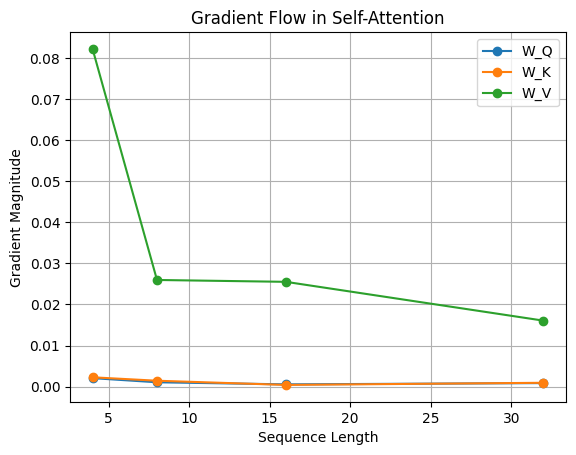

In [9]:
gradient_results = np.array(
    gradient_results
)

plt.plot(
    sequence_lengths,
    gradient_results[:, 0],
    marker="o",
    label="W_Q"
)

plt.plot(
    sequence_lengths,
    gradient_results[:, 1],
    marker="o",
    label="W_K"
)

plt.plot(
    sequence_lengths,
    gradient_results[:, 2],
    marker="o",
    label="W_V"
)

plt.xlabel("Sequence Length")
plt.ylabel("Gradient Magnitude")
plt.title("Gradient Flow in Self-Attention")
plt.legend()
plt.grid()
plt.show()

## Conclusion

The custom Transformer backward pass was successfully implemented without PyTorch Autograd. Gradients were manually calculated for the Query, Key, and Value matrices and their projection weights \(W_Q\), \(W_K\), and \(W_V\). Gradient magnitudes were tracked across different sequence lengths to analyze gradient flow in the attention mechanism.